In [61]:
import pandas as pd
import numpy as np

In [62]:
df = pd.read_csv("powerplant_data.csv")

In [63]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [64]:
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

# PE => produced energy

In [65]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [66]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [67]:
y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


In [68]:
# Split out data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [69]:
df.shape

(9568, 5)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]])

In [72]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [73]:
type(X_train_scaled)

numpy.ndarray

In [74]:
type(y_train)
y_train.shape

(7654,)

In [75]:
#DataLoader class helps in creating batches for mini batch GD
#It also shuffles the data and used to define how the data will be loaded for training

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [76]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Deep Learning

In [77]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)

In [78]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [59]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/50 ==> train loss = 205800.0619140625 & val loss = 203924.96875
epoch 2/50 ==> train loss = 196454.37024739583 & val loss = 184491.890625
epoch 3/50 ==> train loss = 163521.33821614584 & val loss = 139091.28125
epoch 4/50 ==> train loss = 110752.563671875 & val loss = 83891.90625
epoch 5/50 ==> train loss = 62036.45017089844 & val loss = 45300.92578125
epoch 6/50 ==> train loss = 35044.59996744792 & val loss = 27778.853515625
epoch 7/50 ==> train loss = 23382.1 & val loss = 20024.5859375
epoch 8/50 ==> train loss = 17918.043025716146 & val loss = 15826.18359375
epoch 9/50 ==> train loss = 14388.318483479818 & val loss = 12670.1259765625
epoch 10/50 ==> train loss = 11390.746189371745 & val loss = 9808.4521484375
epoch 11/50 ==> train loss = 8616.507489013671 & val loss = 7209.40478515625
epoch 12/50 ==> train loss = 6187.53624979655 & val loss = 5034.4208984375
epoch 13/50 ==> train loss = 4229.422122701009 & val loss = 3374.68701171875
epoch 14/50 ==> train loss = 2792.6220336

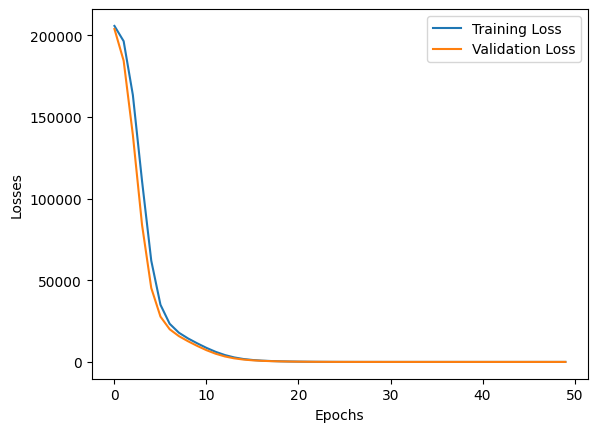

In [60]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()